# Custom Model

The custom model allows to implement a custom comput function as shown below.

<img src = "./model.svg" width=150px>

## Model equations

Model equations are implemented during runtime.

## Parameters

Paaramters are dynamic.



## Implementation of the model



In [2]:
from simunetcore import Model

# Model implementation for the Custom model
class Custom(Model):
    def __init__(self, name:str=""):
        Model.__init__(self, name)

        # Model parameters
        self.compute_scr = ""
                        
    def compute(self, *args, **kwargs):
        try:
            exec(self.compute_scr)
        except:
            raise

## Computation of the model

In [18]:
import numpy as np
# Create model
M_3 = Custom("M_3")

# Model parameters
M_3.params = {
    "param_1": {"value": 10.0, "description": "Parameter 1", "unit": "1"},
}
# Model variables (The units have to match the units of the connected vars)
M_3.vars = {
    "var_1": {"description": "Variable 1", "unit": "m"},
    "var_2": {"description": "Variable 2", "unit": "K"},
    "var_3": {"description": "Variable 3", "unit": "1"},
}
# Model inputs
M_3.u = {
    "u_1": {"type": "liquid", "description": "Input 1", "vars": ["var_1", "var_2"]},
}
# Model outputs
M_3.y = {
    "y_1": {"type": "liquid", "description": "Output 1", "vars": ["var_3"]}
}
# Port adjacencies (Remove if not used)
M_3.adj = [
    ["u_1", "y_1"]
]

M_3.compute_scr = """
import numpy as np

# Get parameters

param_1 = self.get_param("param_1")

# Get input vars
var_1 = self.get_var("var_1")
var_2 = self.get_var("var_2")

# Get time
t = self.get_t()

# Compute output vars

var_3 = np.array(var_1) * np.array(var_2) - np.array(t) * param_1

# Store results
self.set_var("var_3", var_3)

"""

# Setup integration time
t_start = 0.0
t_end = 300.0
numpoints = 51
M_3.set_t(np.linspace(t_start, t_end, numpoints))

# Setup imput vector
var_1 = [100] #np.linspace(100.0, 300.0, numpoints)
var_2 = [100] #np.linspace(1.0, 100, numpoints)
u_1 = [var_1, var_2]
M_3.set_u("u_1", u_1)

# Solve model
M_3.compute()

## Results

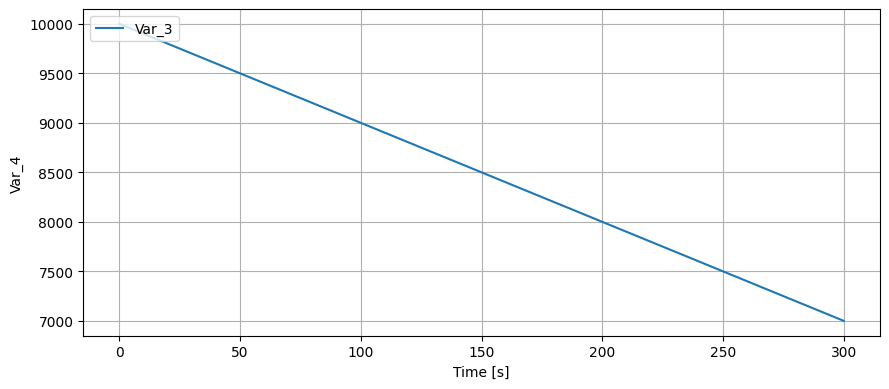

In [19]:
import matplotlib
import matplotlib.pyplot as plt

# Create figure
plt.figure(figsize=(9, 4))

# Plot values
ln_1 = plt.plot(M_3.get_t(), M_3.get_var("var_3"), "C0", label="Var_3")
plt.grid()
plt.xlabel("Time [s]")
plt.ylabel("Var_4")

plt.legend(loc=2)  

# Layout and show
plt.tight_layout()
plt.show()